# Optuna: Dynamic Hyperparameter Optimization Framework

## 1. Introduction & Overview
**Optuna** is an open-source automatic hyperparameter optimization framework designed for Machine Learning and Deep Learning models. It replaces traditional methods like Grid Search and Random Search with efficient automated optimization algorithms.

### Core Concepts in Optuna:
- **Study:** The overall optimization process consisting of multiple trial evaluations.
- **Trial:** A single execution of the target objective function using a sampled set of hyperparameters.
- **Objective Function:** A custom function that takes a `trial` object, sets up model hyperparameters, evaluates model performance, and returns a score.
- **Define-by-Run API:** Allows flexible, dynamic hyperparameter search spaces constructed using standard Python syntax.
-

## 2. Pros and Cons of Optuna

### Pros:
1. **Efficient Sampling Algorithms:** Uses Tree-structured Parzen Estimator (TPE) by default, making convergence faster than random search.
2. **Automated Pruning (Early Stopping):** Automatically terminates unpromising trials early to save computation time.
3. **Seamless Integration:** Works with PyTorch, TensorFlow, Scikit-Learn, XGBoost, LightGBM, and CatBoost.
4. **Interactive Visualizations:** Built-in interactive plots using Plotly (Optimization History, Parameter Importances).

### Cons:
1. **Computational Overhead:** Requires running dozens of trials to reach peak convergence on large datasets.
2. **Reproducibility Setup:** Requires explicit random seeds across libraries for fully deterministic results.


In [2]:
import optuna
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
# Hide detailed trial logs during optimization
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [4]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101, stratify=y)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (455, 30)
Test shape: (114, 30)


In [12]:
def optuna_function(trial):
    # Suggest hyperparameter search ranges
    trees = trial.suggest_int('n_estimators', 20, 150)
    tree_depth = trial.suggest_int('max_depth', 3, 15)
    min_split = trial.suggest_int('min_samples_split', 2, 8)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    
    # Initialize classifier
    model = RandomForestClassifier(
        n_estimators=trees,
        max_depth=tree_depth,
        min_samples_split=min_split,
        criterion=criterion,
        random_state=42)
    # 5-fold cross validation score
    c_score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    return c_score

In [13]:
# Create optimization study
optuna_study = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=101))
# Run optimization across 25 trials
optuna_study.optimize(optuna_function, n_trials=20)
print("Optimization Completed!")
print(f"Best Validation Accuracy: {optuna_study.best_value * 100:.2f}%\n")
print("Best Hyperparameters Found:")
for param, val in optuna_study.best_params.items():
    print(f"  * {param}: {val}")

Optimization Completed!
Best Validation Accuracy: 96.26%

Best Hyperparameters Found:
  * n_estimators: 103
  * max_depth: 6
  * min_samples_split: 5
  * criterion: entropy


In [17]:
# Train model using best parameters
final_model = RandomForestClassifier(**optuna_study.best_params, random_state=42)
final_model.fit(X_train, y_train)
# Predictions & evaluation
predictions = final_model.predict(X_test)
final_acc = accuracy_score(y_test, predictions)

print(f"Final Test Accuracy: {final_acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test,predictions, target_names=cancer_data.target_names))

Final Test Accuracy: 96.49%

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.93      0.95        42
      benign       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



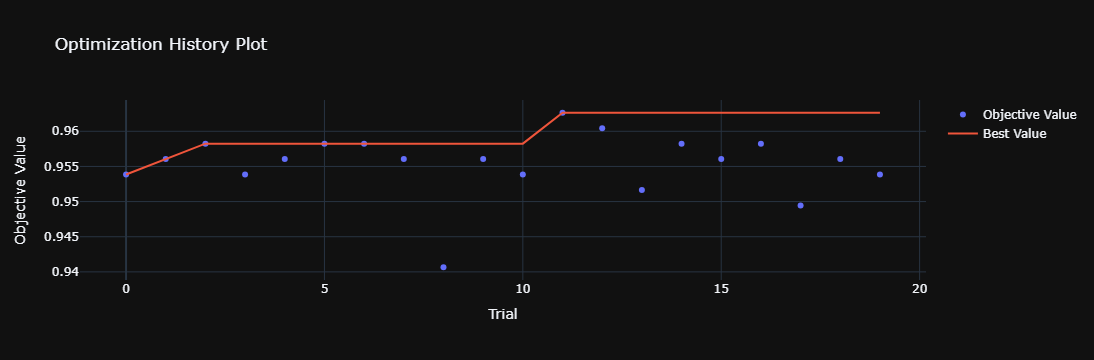

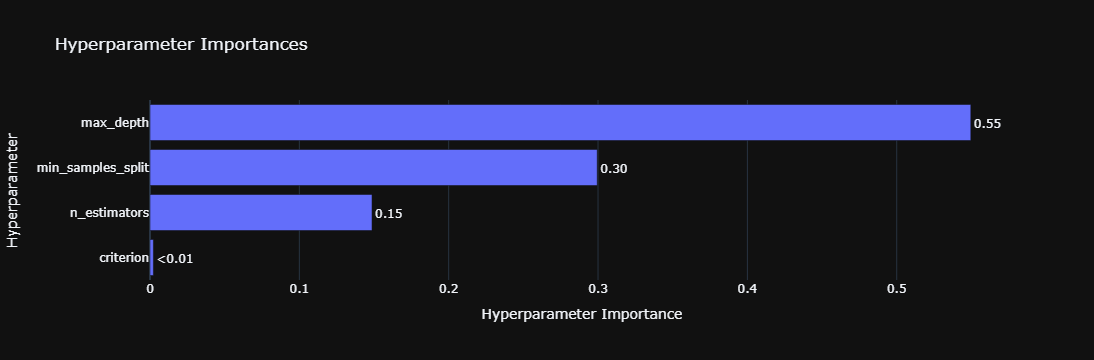

In [19]:
# Plot optimization progress over trials
plot = optuna.visualization.plot_optimization_history(optuna_study)
plot.update_layout(template="plotly_dark")
plot.show()
# Plot relative importance of each hyperparameter
importanc_plot = optuna.visualization.plot_param_importances(optuna_study)
importanc_plot.update_layout(template="plotly_dark")
importanc_plot.show()